In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.linear_model import LinearRegression 

sns.set()

### Load data


In [2]:
data_preprocessed = pd.read_csv('preprocessed_data.csv')

In [3]:
data_preprocessed.head()

,log price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,8.342840,277,2.0,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,8.974618,427,2.9,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,9.495519,358,5.0,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,10.043249,240,4.2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,9.814656,120,2.0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


### Linear Regression Model

In [8]:
target = data_preprocessed['log price']
inputs = data_preprocessed.drop('log price', axis=1)

### Standardiazation


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

StandardScaler()

In [11]:
scaled_inputs = scaler.transform(inputs)

### Test and Train Split

In [12]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(scaled_inputs,target)

### Create Regression

In [13]:
reg = LinearRegression()

reg.fit(x_train,y_train)

LinearRegression()

In [14]:
y_hat = reg.predict(x_train)

[]

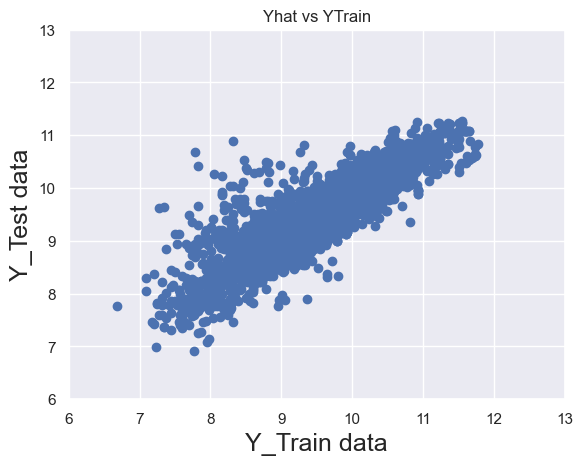

In [20]:
plt.scatter(y_train,y_hat)
plt.title('Yhat vs YTrain')
plt.xlabel('Y_Train data',size = 18)
plt.ylabel('Y_Test data', size = 18)
plt.xlim(6,13)
plt.ylim(6,13)
plt.plot()

C:\Users\kushw\AppData\Local\Temp\ipykernel_13076\1329618742.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train - y_hat)


Text(0.5, 1.0, 'Residual Pdf')

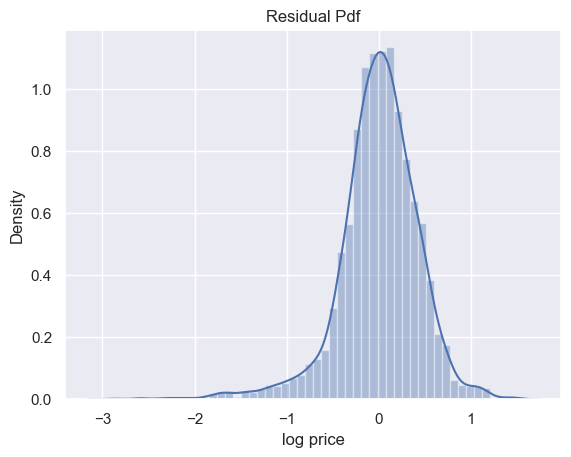

In [23]:
sns.distplot(y_train - y_hat)
plt.title('Residual Pdf')

In [26]:
reg.score(x_train,y_train)


0.7488177371551257

### Finding Weight and bais

In [28]:
reg.coef_

array([-0.4575112 ,  0.21529688,  0.01496718,  0.01563089, -0.13323589,
       -0.179399  , -0.05106818, -0.07868534, -0.15654654, -0.09722623,
       -0.18918547, -0.11148471, -0.15618489, -0.11770377, -0.03059388,
       -0.14297245,  0.31072095])

In [29]:
reg.intercept_

9.412749831211517

In [32]:
reg_summaary = pd.DataFrame(inputs.columns.values, columns=['Features'])
reg_summaary['Weight'] = reg.coef_
reg_summaary

,Features,Weight
0,Mileage,-0.457511
1,EngineV,0.215297
2,Brand_BMW,0.014967
3,Brand_Mercedes-Benz,0.015631
4,Brand_Mitsubishi,-0.133236
5,Brand_Renault,-0.179399
6,Brand_Toyota,-0.051068
7,Brand_Volkswagen,-0.078685
8,Body_hatch,-0.156547
9,Body_other,-0.097226


#### price comapred with audi

### TESTING

In [37]:
y_hat_test = reg.predict(x_test)

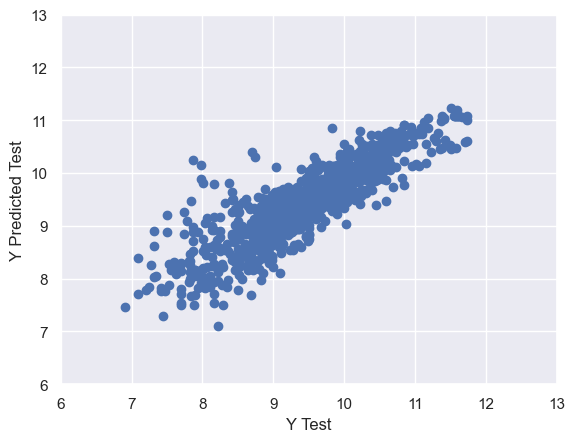

In [42]:
plt.scatter(y_test, y_hat_test)
plt.xlabel('Y Test' , size = 12)
plt.ylabel('Y Predicted Test', size = 12)
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

### Summary

In [46]:
pf_df = pd.DataFrame(np.exp(y_hat_test),columns=['Prediction'])
pf_df.head()

,Prediction
0,18936.310803
1,24617.452569
2,11228.699540
3,23920.807468
4,64880.026867


In [50]:
y_test = y_test.reset_index(drop=True)
y_test.head()

0    10.431170
1    10.268131
2     9.268609
3    10.092926
4    11.545712
Name: log price, dtype: float64

In [51]:
pf_df['Target'] = np.exp(y_test)
pf_df

,Prediction,Target
0,18936.310803,33900.00
1,24617.452569,28800.00
2,11228.699540,10600.00
3,23920.807468,24171.42
4,64880.026867,103333.00
...,...,...
962,17878.909592,13900.00
963,5424.744607,3300.00
964,9875.171110,7000.00
965,7793.516839,6750.00


In [52]:
pf_df['Residual'] = pf_df['Target'] - pf_df['Prediction']

In [54]:
pf_df['Diffrence %'] = np.absolute(pf_df['Residual']/pf_df['Target']*100)
pf_df

,Prediction,Target,Residual,Diffrence %
0,18936.310803,33900.00,14963.689197,44.140676
1,24617.452569,28800.00,4182.547431,14.522734
2,11228.699540,10600.00,-628.699540,5.931128
3,23920.807468,24171.42,250.612532,1.036813
4,64880.026867,103333.00,38452.973133,37.212675
...,...,...,...,...
962,17878.909592,13900.00,-3978.909592,28.625249
963,5424.744607,3300.00,-2124.744607,64.386200
964,9875.171110,7000.00,-2875.171110,41.073873
965,7793.516839,6750.00,-1043.516839,15.459509


In [55]:
pf_df.sort_values(by=['Diffrence %'])

,Prediction,Target,Residual,Diffrence %
845,23198.656077,23200.0,1.343923,0.005793
194,13605.330809,13600.0,-5.330809,0.039197
172,24512.070040,24500.0,-12.070040,0.049265
867,9493.590279,9500.0,6.409721,0.067471
526,7192.997972,7200.0,7.002028,0.097250
...,...,...,...,...
11,9945.538680,1800.0,-8145.538680,452.529927
470,18087.831478,2999.0,-15088.831478,503.128759
941,19560.076756,2900.0,-16660.076756,574.485405
765,25717.210966,2900.0,-22817.210966,786.800378
